# Прогнозирование спроса на поездки такси по времени и району

В этом ноутбуке реализован полный пайплайн решения задачи прогнозирования почасового спроса на такси по районам города.

Цель работы - построить модель, которая по историческим данным о поездках, календарным признакам, погоде и предыдущей динамике спроса прогнозирует количество поездок на следующие 24 часа для каждого района.

В работе рассматриваются несколько подходов:

- простые baseline-модели;
- линейная модель RidgeRegression;
- ранняя LSTM-архитектура из первой версии работы;
- финальная residual LSTM-модель.

Итоговое качество моделей сравнивается по метрикам MAE, RMSE, WAPE, sMAPE и R^2.

## 1. Импорт библиотек и настройка эксперимента

В этом разделе подключаются библиотеки для обработки данных, визуализации, построения моделей и оценки качества.

Также задаются основные параметры:

- период данных;
- длина исторического окна;
- горизонт прогноза;
- шаг формирования последовательностей;
- пропорции train/validation/test;
- параметры обучения нейросетей.

Для воспроизводимости фиксируется `RANDOM_STATE`. Если доступна видеокарта, TensorFlow будет использовать GPU, при этом включается режим постепенного выделения памяти, чтобы снизить риск падения kernel из-за нехватки видеопамяти.

In [1]:
import warnings
from pathlib import Path

import holidays
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from meteostat import Stations, Hourly

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

import tensorflow as tf
from tensorflow.keras import Model, Input, callbacks
from tensorflow.keras.layers import (
    LSTM,
    Dropout,
    Dense,
    Add,
    BatchNormalization,
    Embedding,
    Flatten,
    Concatenate,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

from joblib import dump

warnings.filterwarnings("ignore")

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("GPU:", gpus)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

START_DATE = pd.Timestamp("2024-01-01")
MAX_DATE = pd.Timestamp("2025-04-01")

PAST_STEPS = 72
FUTURE_STEPS = 24
SEQUENCE_STRIDE = 24

N_TOP_LOCATIONS = None

TRAIN_SIZE = 0.7
VAL_SIZE = 0.15

BATCH_SIZE = 32
EPOCHS = 15


GPU: []


## 2. Постановка задачи

Задача формулируется как задача прогнозирования временного ряда с учетом пространственного признака района.

Для каждого района города формируется почасовой временной ряд:

`datetime + location_id -> trips_count`

где:

- `datetime` - конкретный час;
- `location_id` - идентификатор района;
- `trips_count` - количество поездок, начавшихся в этом районе в этот час.

Модель получает на вход историю за последние 72 часа и прогнозирует спрос на следующие 24 часа:

- вход: последовательность длиной 72 часа;
- выход: вектор длиной 24 значения;
- целевая переменная: `trips_count`;
- тип задачи: регрессия временного ряда;
- разрез прогноза: район + час.

## 3. Загрузка сырых данных

В качестве источника используются parquet-файлы с поездками такси. В данных встречаются разные типы поездок: Yellow Taxi, Green Taxi и High Volume FHV. У этих наборов отличаются названия колонок, поэтому на этапе загрузки они приводятся к единому формату.

Для дальнейшего прогноза спроса используются два поля:

- `pickup_datetime` - время начала поездки;
- `location_id` - район начала поездки.

После загрузки выполняются базовые проверки:

- преобразование времени к `datetime`;
- преобразование района к числовому типу;
- удаление строк с пропущенным временем или районом;
- фильтрация некорректных районов;
- ограничение периода исследования;
- округление времени до часа.

На этом этапе не удаляются строки с одинаковыми `datetime` и `location_id`, потому что несколько поездок в одном районе и в один час являются не дубликатами, а реальным спросом.

In [2]:
def find_data_dir() -> Path:
    current_dir = Path().resolve()

    candidates = [
        current_dir / "taxi-data",
    ]

    for path in candidates:
        if path.exists() and any(path.glob("*.parquet")):
            return path

    raise FileNotFoundError("Не найдена папка с parquet-файлами: taxi-data")

def load_raw_data() -> pd.DataFrame:
    target_dir = find_data_dir()
    file_paths = sorted(target_dir.glob("*.parquet"))

    dfs = []

    for path in file_paths:
        df = pd.read_parquet(path)
        fname = str(path).lower()

        if "yellow" in fname:
            df = df.rename(
                columns={
                    "tpep_pickup_datetime": "pickup_datetime",
                    "PULocationID": "location_id",
                }
            )

        elif "green" in fname:
            df = df.rename(
                columns={
                    "lpep_pickup_datetime": "pickup_datetime",
                    "PULocationID": "location_id",
                }
            )

        elif "fhvhv" in fname:
            df = df.rename(
                columns={
                    "pickup_datetime": "pickup_datetime",
                    "PULocationID": "location_id",
                }
            )

        if "pickup_datetime" in df.columns and "location_id" in df.columns:
            df = df[["pickup_datetime", "location_id"]].copy()

            df["pickup_datetime"] = pd.to_datetime(
                df["pickup_datetime"], errors="coerce"
            )
            df["location_id"] = pd.to_numeric(df["location_id"], errors="coerce")

            df = df.dropna(subset=["pickup_datetime", "location_id"])

            df["location_id"] = df["location_id"].astype("int16")

            df = df[
                (df["location_id"] > 0)
                & (df["location_id"] <= 265)
                & (df["pickup_datetime"] >= START_DATE)
                & (df["pickup_datetime"] < MAX_DATE)
            ]

            df["datetime"] = df["pickup_datetime"].dt.floor("h")

            df = df[["datetime", "location_id"]]

            dfs.append(df)

    if not dfs:
        raise ValueError("Не удалось прочитать ни один подходящий parquet-файл")

    combined = pd.concat(dfs, ignore_index=True).reset_index(drop=True)
    combined = combined.sort_values(["location_id", "datetime"]).reset_index(drop=True)

    return combined

## 4. Агрегация поездок и формирование полной почасовой сетки

После загрузки каждая строка соответствует отдельной поездке. Для задачи прогнозирования спроса данные агрегируются до уровня:

`datetime + location_id -> trips_count`

То есть для каждого района и часа считается количество поездок.

Дополнительно формируется полная сетка всех комбинаций:

`все часы × все районы`

Это важный этап для корректной работы с временными рядами. Если в каком-то районе в определенный час поездок не было, такая комбинация должна присутствовать в данных с `trips_count = 0`.

Без полной сетки временной ряд был бы неполным: модель видела бы только активные часы и не учитывала бы периоды отсутствия спроса.

In [3]:
def aggregate_trips(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])

    result = (
        df.groupby(["datetime", "location_id"]).size().reset_index(name="trips_count")
    )

    result["trips_count"] = result["trips_count"].astype("float32")

    return result

def get_valid_time_bounds(df: pd.DataFrame) -> tuple[pd.Timestamp, pd.Timestamp]:
    daily_total = (
        df.groupby(df["datetime"].dt.normalize())["trips_count"].sum().sort_index()
    )

    positive_days = daily_total[daily_total > 0]

    if positive_days.empty:
        raise ValueError("После фильтрации не осталось дней с поездками")

    threshold = max(100, positive_days.median() * 0.05)

    valid_days = daily_total[daily_total >= threshold]

    if valid_days.empty:
        start_time = positive_days.index.min()
        end_time = positive_days.index.max() + pd.Timedelta(days=1)
    else:
        start_time = valid_days.index.min()
        end_time = valid_days.index.max() + pd.Timedelta(days=1)

    print("Порог валидного дня:", threshold)
    print("Первый валидный день:", start_time)
    print("Последний валидный день включительно:", end_time - pd.Timedelta(days=1))

    return start_time, end_time

def complete_hourly_grid(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])

    start_time, end_time = get_valid_time_bounds(df)

    df = df[(df["datetime"] >= start_time) & (df["datetime"] < end_time)].copy()

    if N_TOP_LOCATIONS is not None:
        top_locations = (
            df.groupby("location_id")["trips_count"]
            .sum()
            .sort_values(ascending=False)
            .head(N_TOP_LOCATIONS)
            .index
        )
        df = df[df["location_id"].isin(top_locations)].copy()

    locations = np.sort(df["location_id"].unique())
    hours = pd.date_range(start_time, end_time - pd.Timedelta(hours=1), freq="h")

    grid = pd.MultiIndex.from_product(
        [locations, hours], names=["location_id", "datetime"]
    ).to_frame(index=False)

    result = grid.merge(df, on=["location_id", "datetime"], how="left")
    result["trips_count"] = result["trips_count"].fillna(0).astype("float32")
    result = result.sort_values(["location_id", "datetime"]).reset_index(drop=True)

    return result

## 5. Формирование признаков

Для повышения качества прогноза к исходному временному ряду добавляются дополнительные признаки.
Используются несколько групп признаков.

### Календарные признаки

Календарные признаки помогают модели учитывать регулярные шаблоны спроса:

- час суток;
- день недели;
- месяц;
- выходной день;
- праздник;
- день перед праздником;
- день после праздника;
- начало и конец месяца.

### Циклические признаки

Час суток и день недели имеют циклическую природу, поэтому для них используются синусно-косинусные преобразования:

- `hour_sin`, `hour_cos`;
- `dow_sin`, `dow_cos`.

Так модель лучше учитывает близость временных значений на границах периода.

### Лаговые признаки

Лаги отражают предыдущие значения спроса:

- `lag_1h` - спрос час назад;
- `lag_24h` - спрос в тот же час предыдущего дня;
- `lag_168h` - спрос в тот же час неделю назад.

Эти признаки важны, потому что спрос на такси обладает инерцией и сезонностью.

### Rolling-признаки

Скользящие статистики за 168 часов позволяют учитывать средний недельный уровень спроса:

- среднее;
- медиана;
- стандартное отклонение.

### Погодные признаки

Погодные условия могут влиять на спрос. Например, осадки или сильный ветер могут увеличивать потребность в такси. Поэтому добавляются:

- температура;
- осадки;
- скорость ветра.

In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    us_holidays = holidays.US()

    df["datetime"] = pd.to_datetime(df["datetime"])
    df["date"] = df["datetime"].dt.normalize()
    df["hour"] = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["month"] = df["datetime"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype("int8")
    df["is_holiday"] = (
        df["date"].dt.date.apply(lambda d: int(d in us_holidays)).astype("int8")
    )
    df["is_month_start"] = df["date"].dt.is_month_start.astype("int8")
    df["is_month_end"] = df["date"].dt.is_month_end.astype("int8")
    df["day_of_year"] = df["date"].dt.dayofyear.astype("int16")
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype("int16")

    df["is_pre_holiday"] = (
        (df["date"] + pd.Timedelta(days=1))
        .dt.date.apply(lambda d: int(d in us_holidays))
        .astype("int8")
    )

    df["is_post_holiday"] = (
        (df["date"] - pd.Timedelta(days=1))
        .dt.date.apply(lambda d: int(d in us_holidays))
        .astype("int8")
    )

    df = df.sort_values(["location_id", "datetime"]).reset_index(drop=True)

    group = df.groupby("location_id")["trips_count"]

    df["lag_1h"] = group.shift(1).fillna(0).astype("float32")
    df["lag_24h"] = group.shift(24).fillna(0).astype("float32")
    df["lag_168h"] = group.shift(168).fillna(0).astype("float32")

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24).astype("float32")
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24).astype("float32")
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7).astype("float32")
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7).astype("float32")

    roll = group.rolling(168, min_periods=1)

    df["roll_168h_mean"] = roll.mean().reset_index(level=0, drop=True).astype("float32")
    df["roll_168h_median"] = (
        roll.median().reset_index(level=0, drop=True).astype("float32")
    )
    df["roll_168h_std"] = (
        roll.std().reset_index(level=0, drop=True).fillna(0).astype("float32")
    )

    df["time_idx"] = df.groupby("location_id").cumcount().astype("int32")

    return df


def merge_weather(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    try:
        start = df["datetime"].min().to_pydatetime()
        end = (df["datetime"].max() + pd.Timedelta(hours=1)).to_pydatetime()

        station = Stations().nearby(40.7128, -74.0060).fetch(1).index[0]
        weather = Hourly(station, start, end).fetch().reset_index()

        weather["datetime"] = weather["time"].dt.floor("h")
        weather = weather[["datetime", "temp", "prcp", "wspd"]]

        df = df.merge(weather, on="datetime", how="left")

    except Exception as e:
        print("Погодные данные не загружены:", e)
        df["temp"] = np.nan
        df["prcp"] = np.nan
        df["wspd"] = np.nan

    for col in ["temp", "prcp", "wspd"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].median())
        df[col] = df[col].fillna(0).astype("float32")

    return df


def save_data(df: pd.DataFrame, output: str = "result_lstm.csv") -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["location_id", "datetime"]).reset_index(drop=True)
    df.to_csv(output, index=False)
    df.head(100).to_csv("result_lstm_test.csv", index=False)
    return df


def pipeline() -> pd.DataFrame:
    raw = load_raw_data()
    print("Последний час с реальными поездками:", raw["datetime"].max())

    aggregated = aggregate_trips(raw)
    print("Последний час после агрегации:", aggregated["datetime"].max())

    completed = complete_hourly_grid(aggregated)
    featured = engineer_features(completed)
    with_weather = merge_weather(featured)
    result = save_data(with_weather)

    return result

## 6. Запуск пайплайна подготовки данных

На этом этапе последовательно выполняются все шаги подготовки данных:

1. загрузка сырых parquet-файлов;
2. агрегация поездок по часу и району;
3. формирование полной почасовой сетки;
4. добавление календарных, лаговых, rolling- и погодных признаков;
5. сохранение итогового датасета.

После выполнения пайплайна проверяется размерность данных, количество районов, период наблюдений и доля часов с нулевым спросом.

In [5]:
df = pipeline()

display(df.head())
display(df.info())

print("Размер итогового датасета:", df.shape)
print("Количество районов:", df["location_id"].nunique())
print("Период:", df["datetime"].min(), "-", df["datetime"].max())
print("Доля нулевых часов:", (df["trips_count"] == 0).mean())

Последний час с реальными поездками: 2025-03-23 20:00:00
Последний час после агрегации: 2025-03-23 20:00:00
Порог валидного дня: 5872.725
Первый валидный день: 2024-01-01 00:00:00
Последний валидный день включительно: 2025-02-28 00:00:00


,location_id,datetime,trips_count,date,hour,day_of_week,month,is_weekend,is_holiday,is_month_start,...,hour_cos,dow_sin,dow_cos,roll_168h_mean,roll_168h_median,roll_168h_std,time_idx,temp,prcp,wspd
0,1,2024-01-01 00:00:00,0.0,2024-01-01,0,0,1,0,1,1,...,1.000000,0.0,1.0,0.0,0.0,0.0,0,6.0,0.0,11.0
1,1,2024-01-01 01:00:00,0.0,2024-01-01,1,0,1,0,1,1,...,0.965926,0.0,1.0,0.0,0.0,0.0,1,5.6,0.0,11.2
2,1,2024-01-01 02:00:00,0.0,2024-01-01,2,0,1,0,1,1,...,0.866025,0.0,1.0,0.0,0.0,0.0,2,5.6,0.0,9.4
3,1,2024-01-01 03:00:00,0.0,2024-01-01,3,0,1,0,1,1,...,0.707107,0.0,1.0,0.0,0.0,0.0,3,5.6,0.0,9.4
4,1,2024-01-01 04:00:00,0.0,2024-01-01,4,0,1,0,1,1,...,0.500000,0.0,1.0,0.0,0.0,0.0,4,5.6,0.0,9.4


<class 'pandas.DataFrame'>
RangeIndex: 2682600 entries, 0 to 2682599
Data columns (total 29 columns):
 #   Column            Dtype         
---  ------            -----         
 0   location_id       int16         
 1   datetime          datetime64[us]
 2   trips_count       float32       
 3   date              datetime64[us]
 4   hour              int32         
 5   day_of_week       int32         
 6   month             int32         
 7   is_weekend        int8          
 8   is_holiday        int8          
 9   is_month_start    int8          
 10  is_month_end      int8          
 11  day_of_year       int16         
 12  week_of_year      int16         
 13  is_pre_holiday    int8          
 14  is_post_holiday   int8          
 15  lag_1h            float32       
 16  lag_24h           float32       
 17  lag_168h          float32       
 18  hour_sin          float32       
 19  hour_cos          float32       
 20  dow_sin           float32       
 21  dow_cos           f

None

Размер итогового датасета: (2682600, 29)
Количество районов: 263
Период: 2024-01-01 00:00:00 - 2025-02-28 23:00:00
Доля нулевых часов: 0.47052598225602027


## 7. Первичный анализ данных

Перед обучением моделей проводится EDA - предварительный анализ данных, цель которого:

- понять распределение спроса по часам суток;
- выявить различия спроса по дням недели;
- найти районы с наибольшим количеством поездок;
- оценить диапазоны значений признаков;
- проверить наличие нулевых и экстремальных значений.

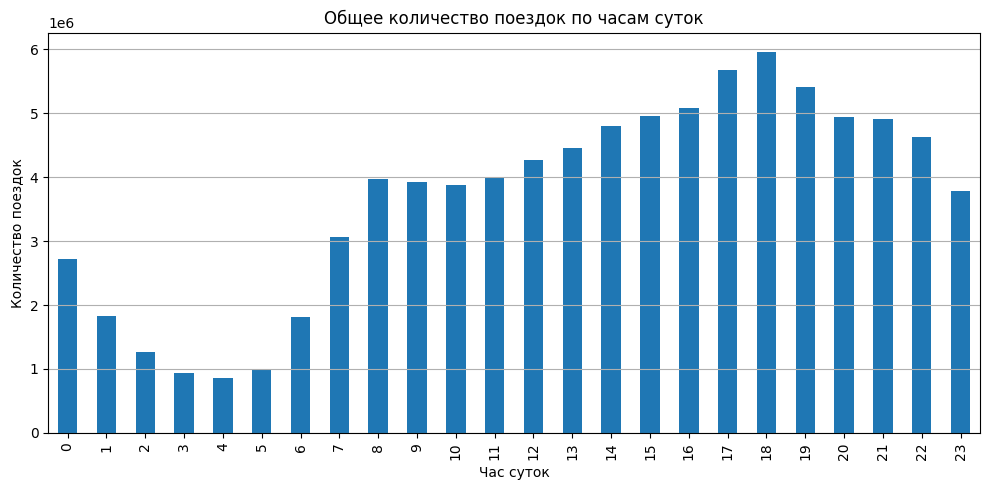

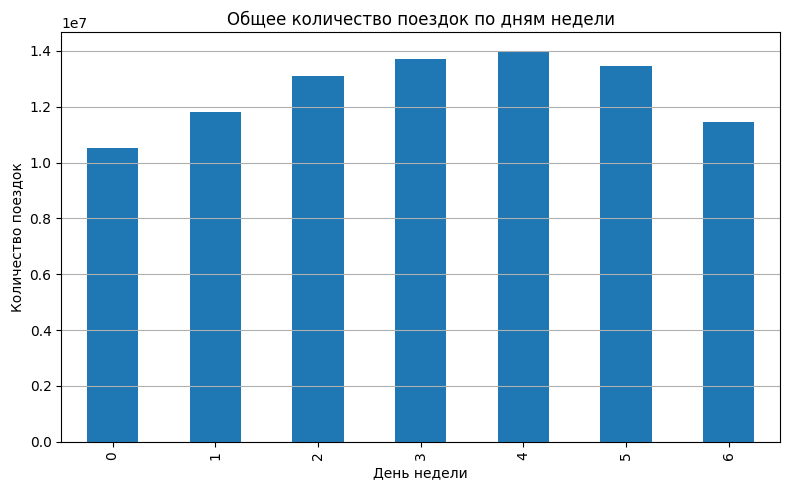

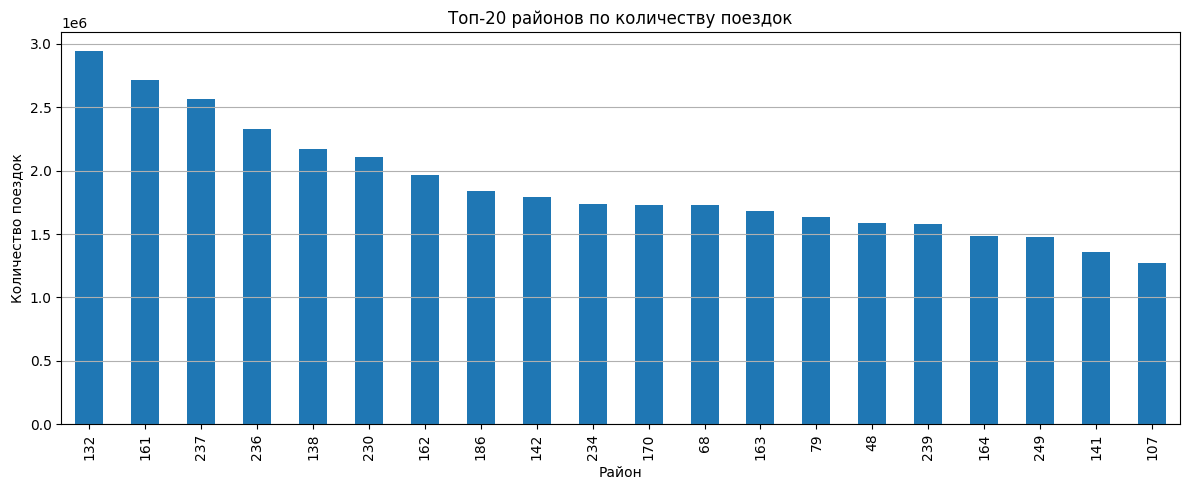

,count,mean,std,min,25%,50%,75%,max
trips_count,2682600.0,32.827293,87.138130,0.0,0.0,1.0,15.0,2364.000000
temp,2682600.0,12.659616,9.659705,-11.4,4.4,11.7,21.1,34.400002
prcp,2682600.0,0.118059,0.609321,0.0,0.0,0.0,0.0,14.400000
wspd,2682600.0,10.748676,6.627758,0.0,7.6,9.4,14.8,46.400002
lag_1h,2682600.0,32.807747,87.090675,0.0,0.0,1.0,15.0,2364.000000
lag_24h,2682600.0,32.491898,86.607330,0.0,0.0,1.0,14.0,2364.000000
lag_168h,2682600.0,30.726460,83.814667,0.0,0.0,1.0,11.0,2364.000000


In [6]:
plt.figure(figsize=(10, 5))
df.groupby("hour")["trips_count"].sum().plot(kind="bar")
plt.title("Общее количество поездок по часам суток")
plt.xlabel("Час суток")
plt.ylabel("Количество поездок")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("eda_trips_by_hour.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
df.groupby("day_of_week")["trips_count"].sum().plot(kind="bar")
plt.title("Общее количество поездок по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество поездок")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("eda_trips_by_weekday.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
df.groupby("location_id")["trips_count"].sum().sort_values(ascending=False).head(
    20
).plot(kind="bar")
plt.title("Топ-20 районов по количеству поездок")
plt.xlabel("Район")
plt.ylabel("Количество поездок")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("eda_top_locations.png", dpi=150)
plt.show()

display(
    df[["trips_count", "temp", "prcp", "wspd", "lag_1h", "lag_24h", "lag_168h"]]
    .describe()
    .T
)


## Выводы по первичному анализу данных

По результатам первичного анализа видно, что спрос на такси имеет выраженную временную и пространственную структуру.

### Распределение поездок по часам суток

На графике количества поездок по часам заметна суточная сезонность.

Минимальный спрос наблюдается ночью и ранним утром, примерно с 2 до 5 часов. Это ожидаемо, так как в это время снижается деловая и бытовая активность.

После 6-7 часов спрос начинает расти. Это может быть связано с утренними поездками на работу, в аэропорты и другие точки городской активности.

Наибольшее количество поездок наблюдается во второй половине дня и вечером. Пик приходится примерно на 17-19 часов. Это соответствует вечернему часу пик, когда люди возвращаются с работы, едут на встречи, в аэропорты, домой или в развлекательные районы.

Такой график подтверждает, что для прогноза необходимо учитывать час суток. Поэтому в модель добавлены признаки `hour_sin` и `hour_cos`, которые позволяют представить час как циклический признак.

### Распределение поездок по дням недели

График по дням недели показывает, что спрос распределен неравномерно. Наибольшая активность наблюдается ближе к концу рабочей недели, особенно в четверг и пятницу.

В начале недели спрос ниже, а в воскресенье также наблюдается спад. Это говорит о наличии недельной сезонности.

Поэтому в модель добавлены признаки:

- `day_of_week`;
- `dow_sin`;
- `dow_cos`;
- `is_weekend`.

Эти признаки помогают модели учитывать различия между рабочими и выходными днями, а также повторяющиеся недельные паттерны.

### Распределение спроса по районам

Топ-20 районов по количеству поездок показывает сильную пространственную неоднородность спроса.

Некоторые районы имеют существенно больше поездок, чем остальные. Это может быть связано с аэропортами, деловыми зонами, туристическими районами, вокзалами, крупными транспортными узлами и районами с высокой плотностью населения.

Такой результат подтверждает, что район является важным фактором прогноза. Поэтому в модели используется `location_id`, а в финальной LSTM-модели дополнительно применяется embedding района. Это позволяет модели учитывать различия между районами не только через историю спроса, но и через отдельное представление района.

### Описательные статистики

По таблице описательных статистик видно, что среднее значение `trips_count` составляет около 32.8 поездки на район-час, но стандартное отклонение значительно выше среднего. Это означает, что спрос сильно варьируется: есть много часов с низким или нулевым спросом и отдельные часы/районы с очень высоким спросом.

Минимальное значение `trips_count` равно 0. Это ожидаемо, так как после построения полной почасовой сетки в данных появились часы, когда в конкретном районе поездок не было. Такие значения важно сохранять, потому что они отражают реальное отсутствие спроса.

Лаговые признаки `lag_1h`, `lag_24h` и `lag_168h` имеют близкие средние значения к `trips_count`, что подтверждает наличие временной зависимости: прошлые значения спроса могут быть полезны для прогноза будущих значений.

Погодные признаки также присутствуют в датасете:

- `temp` - температура;
- `prcp` - осадки;
- `wspd` - скорость ветра.

Они добавлены в модель, так как погодные условия могут влиять на спрос такси.

### Общий вывод

EDA подтверждает, что задача прогнозирования спроса на такси не является случайной: в данных есть выраженные закономерности по времени суток, дням недели и районам.

Поэтому для модели используются следующие группы признаков:

- календарные признаки;
- циклические признаки времени;
- лаговые признаки;
- rolling-статистики;
- погодные признаки;
- идентификатор района.

Такая структура признаков соответствует природе задачи и помогает модели учитывать как краткосрочную динамику спроса, так и регулярные суточные и недельные паттерны.

## 8. Формирование обучающих последовательностей

Для обучения LSTM данные преобразуются в формат supervised learning.

Каждый обучающий пример состоит из двух частей:

- входное окно `X`: признаки за предыдущие 72 часа;
- целевой вектор `y`: спрос на следующие 24 часа.

Таким образом, модель учится прогнозировать не одно значение, а сразу 24 значения - почасовой прогноз на следующие сутки.

Параметр `SEQUENCE_STRIDE` задает шаг формирования окон. В текущем эксперименте используется шаг 24 часа, то есть для каждого района формируется один прогнозный пример на сутки. Это снижает вычислительную нагрузку и соответствует сценарию ежедневного построения прогноза на следующий день.

In [7]:
FEATURE_COLS = [
    "trips_count",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_holiday",
    "month",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "day_of_year",
    "week_of_year",
    "is_pre_holiday",
    "is_post_holiday",
    "lag_1h",
    "lag_24h",
    "lag_168h",
    "roll_168h_mean",
    "roll_168h_median",
    "roll_168h_std",
    "time_idx",
    "temp",
    "prcp",
    "wspd",
]


def create_sequences(
    df: pd.DataFrame,
    past_steps: int = PAST_STEPS,
    future_steps: int = FUTURE_STEPS,
    stride: int = SEQUENCE_STRIDE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict[int, int]]:
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values(["location_id", "datetime"]).reset_index(drop=True)

    locs = np.sort(df["location_id"].unique())
    loc2idx = {int(loc): idx for idx, loc in enumerate(locs)}

    seqs = []
    tars = []
    regions = []
    target_start_times = []

    for loc in locs:
        sub = (
            df[df["location_id"] == loc].sort_values("datetime").reset_index(drop=True)
        )

        features = sub[FEATURE_COLS].astype("float32").values
        rides = sub["trips_count"].astype("float32").values
        times = sub["datetime"].values

        last_start = len(sub) - future_steps + 1

        for i in range(past_steps, last_start, stride):
            seqs.append(features[i - past_steps : i])
            tars.append(rides[i : i + future_steps])
            regions.append(loc2idx[int(loc)])
            target_start_times.append(times[i])

    X = np.array(seqs, dtype="float32")
    y = np.array(tars, dtype="float32")
    regions = np.array(regions, dtype="int32")
    target_start_times = np.array(target_start_times)

    return X, y, regions, target_start_times, loc2idx


## 9. Разделение данных на train, validation и test

Так как задача связана с временными рядами, случайное разбиение данных не используется. Вместо этого применяется временной split:

- train - ранний период;
- validation - следующий период;
- test - самый поздний период.

Такой подход имитирует реальный сценарий использования модели: она обучается на прошлом и проверяется на будущем.

Также на этом этапе выполняется масштабирование признаков. `StandardScaler` обучается только на train-части, после чего применяется к validation и test. Это предотвращает утечку информации из будущего периода в обучение.

In [8]:
def get_dynamic_time_masks(
    target_start_times: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.Timestamp, pd.Timestamp]:
    times = pd.to_datetime(target_start_times)
    unique_times = np.array(sorted(pd.Series(times).unique()))

    train_idx = int(len(unique_times) * TRAIN_SIZE)
    val_idx = int(len(unique_times) * (TRAIN_SIZE + VAL_SIZE))

    train_end = pd.Timestamp(unique_times[train_idx])
    val_end = pd.Timestamp(unique_times[val_idx])

    train_mask = np.asarray(times < train_end)
    val_mask = np.asarray((times >= train_end) & (times < val_end))
    test_mask = np.asarray(times >= val_end)

    return train_mask, val_mask, test_mask, train_end, val_end


def fill_nan_by_train_mean(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    n_features = X_train.shape[2]

    means = np.nanmean(X_train.reshape(-1, n_features), axis=0)
    means = np.nan_to_num(means, nan=0.0)

    result = []

    for arr in [X_train, X_val, X_test]:
        arr = arr.copy()
        mask = np.isnan(arr)
        arr[mask] = np.take(means, np.where(mask)[2])
        result.append(arr)

    return tuple(result)


def prepare_data(
    X: np.ndarray,
    y: np.ndarray,
    regions: np.ndarray,
    target_start_times: np.ndarray,
) -> dict:
    train_mask, val_mask, test_mask, train_end, val_end = get_dynamic_time_masks(
        target_start_times
    )

    print("Всего последовательностей:", len(X))
    print("Train sequences:", train_mask.sum())
    print("Val sequences:", val_mask.sum())
    print("Test sequences:", test_mask.sum())
    print("Train end:", train_end)
    print("Val end:", val_end)

    X_train_raw = X[train_mask].copy()
    X_val_raw = X[val_mask].copy()
    X_test_raw = X[test_mask].copy()

    y_train = y[train_mask].copy()
    y_val = y[val_mask].copy()
    y_test = y[test_mask].copy()

    regions_train = regions[train_mask].copy()
    regions_val = regions[val_mask].copy()
    regions_test = regions[test_mask].copy()

    target_train = target_start_times[train_mask]
    target_val = target_start_times[val_mask]
    target_test = target_start_times[test_mask]

    X_train_raw, X_val_raw, X_test_raw = fill_nan_by_train_mean(
        X_train_raw,
        X_val_raw,
        X_test_raw,
    )

    n_features = X_train_raw.shape[2]

    scaler_X = StandardScaler()
    scaler_X.fit(X_train_raw.reshape(-1, n_features))

    def scale_X(arr: np.ndarray) -> np.ndarray:
        flat = arr.reshape(-1, n_features)
        scaled = scaler_X.transform(flat)
        return scaled.reshape(arr.shape).astype("float32")

    X_train_s = scale_X(X_train_raw)
    X_val_s = scale_X(X_val_raw)
    X_test_s = scale_X(X_test_raw)

    data = {
        "X_train_raw": X_train_raw,
        "X_val_raw": X_val_raw,
        "X_test_raw": X_test_raw,
        "X_train": X_train_s,
        "X_val": X_val_s,
        "X_test": X_test_s,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "regions_train": regions_train,
        "regions_val": regions_val,
        "regions_test": regions_test,
        "target_train": target_train,
        "target_val": target_val,
        "target_test": target_test,
        "scaler_X": scaler_X,
        "train_end": train_end,
        "val_end": val_end,
    }

    print(
        "Train:",
        X_train_s.shape,
        pd.to_datetime(target_train).min(),
        pd.to_datetime(target_train).max(),
    )
    print(
        "Val:",
        X_val_s.shape,
        pd.to_datetime(target_val).min(),
        pd.to_datetime(target_val).max(),
    )
    print(
        "Test:",
        X_test_s.shape,
        pd.to_datetime(target_test).min(),
        pd.to_datetime(target_test).max(),
    )
    print("Test y sum:", y_test.sum())
    print("Test zero share:", (y_test == 0).mean())

    return data

## 10. Метрики качества и baseline-модели

Для оценки качества используются несколько метрик.

### MAE

MAE показывает среднюю абсолютную ошибку прогноза в количестве поездок. Эта метрика легко интерпретируется: если MAE равна 26, значит модель в среднем ошибается примерно на 26 поездок.

### RMSE

RMSE сильнее штрафует крупные ошибки. Эта метрика полезна, если особенно важно снижать ошибки в часы высокого спроса.

### WAPE

WAPE показывает отношение суммарной абсолютной ошибки к суммарному фактическому спросу. Эта метрика удобна для интерпретации в процентах и устойчивее MAPE при наличии нулевых значений.

### sMAPE и MAPE_safe

Обычная MAPE плохо работает при нулевых значениях спроса. Поэтому используется безопасная версия с нижней границей знаменателя, а также sMAPE.

### R²

R² показывает, какую долю вариативности целевой переменной объясняет модель.

Для сравнения используются baseline-модели:

- `Naive` - повторяет последнее известное значение;
- `DailySeasonal` - использует значения за последние 24 часа;
- `MovingAverage` - прогнозирует среднее значение за историческое окно;
- `RidgeRegression` - линейная модель на развернутом окне признаков.

In [9]:
def naive_forecast(X_raw: np.ndarray, h: int = FUTURE_STEPS) -> np.ndarray:
    return np.repeat(X_raw[:, -1, 0:1], h, axis=1)


def daily_seasonal_forecast(X_raw: np.ndarray, h: int = FUTURE_STEPS) -> np.ndarray:
    base = X_raw[:, -24:, 0]

    if base.shape[1] != h:
        base = np.repeat(X_raw[:, -1, 0:1], h, axis=1)

    return base.astype("float32")


def moving_average_forecast(
    X_raw: np.ndarray, window: int = PAST_STEPS, h: int = FUTURE_STEPS
) -> np.ndarray:
    mean_values = X_raw[:, -window:, 0].mean(axis=1)
    return np.repeat(mean_values.reshape(-1, 1), h, axis=1).astype("float32")


def make_linear_features(X_scaled: np.ndarray, regions: np.ndarray) -> np.ndarray:
    X_flat = X_scaled.reshape(len(X_scaled), -1)
    regions = regions.reshape(-1, 1).astype("float32")
    return np.hstack([X_flat, regions])

def safe_mape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1.0) -> float:
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)


def smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1.0) -> float:
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return float(np.mean(2 * np.abs(y_true - y_pred) / denom) * 100)


def wape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1.0) -> float:
    total = np.sum(np.abs(y_true))

    if total < eps:
        return np.nan

    return float(np.sum(np.abs(y_true - y_pred)) / total * 100)


def evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_value = safe_mape(y_true, y_pred)
    smape_value = smape(y_true, y_pred)
    wape_value = wape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred, multioutput="uniform_average")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_safe_%": mape_value,
        "sMAPE_%": smape_value,
        "WAPE_%": wape_value,
        "R2": r2,
    }

## 11. Архитектура моделей

В работе сравниваются несколько типов моделей.

### LSTM_direct

`LSTM_direct` - прямая LSTM-модель, напрямую прогнозирует спрос на следующие 24 часа.

Вход модели состоит из двух частей:

- последовательность признаков за предыдущие 72 часа;
- идентификатор района.

Для района используется embedding-слой, что позволяет модели обучить отдельное векторное представление района и учитывать пространственные различия спроса.

### LSTM_residual

`LSTM_residual` строится как коррекция сезонной модели `DailySeasonal`.

Сначала рассчитывается сезонный прогноз, затем LSTM обучается предсказывать остаток:

`residual = fact - DailySeasonal`

Итоговый прогноз:

`forecast = DailySeasonal + alpha * residual_prediction`

Коэффициент `alpha` подбирается на validation-выборке.

Такой подход выбран потому, что в данных есть выраженная суточная сезонность. Нейросеть не должна заново учить весь сезонный паттерн, а может сосредоточиться на исправлении ошибок baseline.

### LSTM_V1_arch

`LSTM_V1_arch` - ранняя архитектура проекта. Она добавлена для сравнения и показывает, как первая версия LSTM работает в новой корректной постановке данных.

Сравнение этих моделей показывает развитие проекта: от первой LSTM-архитектуры к прямой LSTM и далее к residual-подходу.

In [10]:
def build_lstm(input_shape: tuple, n_regions: int, output_steps: int) -> Model:
    seq_input = Input(shape=input_shape, name="seq_input")
    region_input = Input(shape=(), dtype="int32", name="region_input")

    region_emb = Embedding(input_dim=n_regions, output_dim=8, name="region_embedding")(
        region_input
    )
    region_emb = Flatten(name="region_flatten")(region_emb)

    x = LSTM(128, return_sequences=True, name="lstm_1")(seq_input)
    x = BatchNormalization(name="bn_1")(x)
    x = Dropout(0.2, name="dropout_1")(x)

    x = LSTM(64, return_sequences=False, name="lstm_2")(x)
    x = BatchNormalization(name="bn_2")(x)
    x = Dropout(0.2, name="dropout_2")(x)

    x = Concatenate(name="concat_region")([x, region_emb])
    x = Dense(64, activation="relu", name="dense_1")(x)
    x = Dropout(0.2, name="dropout_3")(x)

    out = Dense(output_steps, activation="linear", name="forecast")(x)

    model = Model(
        inputs=[seq_input, region_input], outputs=out, name="LSTM_region_forecast"
    )
    model.compile(optimizer=Adam(learning_rate=1e-3), loss=Huber(), metrics=["mae"])

    return model

In [11]:
def build_lstm_v1_arch(input_shape: tuple, output_steps: int) -> Model:
    seq_input = Input(shape=input_shape, name="seq_input")

    x1 = LSTM(128, return_sequences=True, name="v1_lstm_1")(seq_input)
    x1 = Dropout(0.3, name="v1_dropout_1")(x1)

    x2 = LSTM(128, return_sequences=True, name="v1_lstm_2")(x1)
    x2 = Dropout(0.3, name="v1_dropout_2")(x2)

    x = Add(name="v1_residual_add")([x1, x2])

    x = LSTM(64, return_sequences=False, name="v1_lstm_3")(x)
    x = Dropout(0.2, name="v1_dropout_3")(x)

    out = Dense(output_steps, activation="linear", name="v1_forecast")(x)

    model = Model(inputs=seq_input, outputs=out, name="LSTM_V1_arch")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )

    return model

In [12]:
def build_residual_lstm(input_shape: tuple, n_regions: int, output_steps: int) -> Model:
    seq_input = Input(shape=input_shape, name="seq_input")
    region_input = Input(shape=(), dtype="int32", name="region_input")

    region_emb = Embedding(input_dim=n_regions, output_dim=8, name="region_embedding")(
        region_input
    )
    region_emb = Flatten(name="region_flatten")(region_emb)

    x = LSTM(96, return_sequences=True, name="lstm_1")(seq_input)
    x = Dropout(0.2, name="dropout_1")(x)

    x = LSTM(48, return_sequences=False, name="lstm_2")(x)
    x = Dropout(0.2, name="dropout_2")(x)

    x = Concatenate(name="concat_region")([x, region_emb])
    x = Dense(64, activation="relu", name="dense_1")(x)
    x = Dropout(0.2, name="dropout_3")(x)

    out = Dense(output_steps, activation="linear", name="residual_forecast")(x)

    model = Model(
        inputs=[seq_input, region_input], outputs=out, name="LSTM_residual_forecast"
    )
    model.compile(optimizer=Adam(learning_rate=3e-4), loss="mae", metrics=["mae"])

    return model


def inverse_scaled_residual(y_pred_s: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(y_pred_s.shape)


def choose_best_alpha(
    y_true: np.ndarray, base_pred: np.ndarray, residual_pred: np.ndarray
) -> tuple[float, pd.DataFrame]:
    rows = []

    for alpha in np.linspace(0, 1, 21):
        pred = np.clip(base_pred + alpha * residual_pred, 0, None)
        rows.append(
            {
                "alpha": alpha,
                "MAE": mean_absolute_error(y_true, pred),
                "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
                "WAPE_%": wape(y_true, pred),
            }
        )

    alpha_df = pd.DataFrame(rows)
    best_alpha = float(alpha_df.sort_values("MAE").iloc[0]["alpha"])

    return best_alpha, alpha_df

## 12. Подготовка данных для обучения

Итоговый датасет загружается из файла `result_lstm.csv`, после чего преобразуется в обучающие последовательности.

Далее выполняется временное разделение на train, validation и test, а также масштабирование признаков.

Затем проверяются:

- количество последовательностей;
- размерность train/validation/test;
- временные границы выборок;
- сумма спроса на test;
- доля нулевых значений на test.

In [13]:
df = pd.read_csv("result_lstm.csv", parse_dates=["datetime", "date"])

X, y, regions, target_start_times, loc2idx = create_sequences(
    df,
    past_steps=PAST_STEPS,
    future_steps=FUTURE_STEPS,
    stride=SEQUENCE_STRIDE,
)

data = prepare_data(X, y, regions, target_start_times)

Всего последовательностей: 110986
Train sequences: 77585
Val sequences: 16569
Test sequences: 16832
Train end: 2024-10-25 00:00:00
Val end: 2024-12-27 00:00:00
Train: (77585, 72, 24) 2024-01-04 00:00:00 2024-10-24 00:00:00
Val: (16569, 72, 24) 2024-10-25 00:00:00 2024-12-26 00:00:00
Test: (16832, 72, 24) 2024-12-27 00:00:00 2025-02-28 00:00:00
Test y sum: 4.7316144e+07
Test zero share: 0.07764476394169835


## 13. Обучение baseline-моделей

На этом этапе рассчитывается качество простых моделей.

Baseline-модели нужны для проверки, дает ли LSTM реальное улучшение. Если нейросеть не превосходит простые подходы, ее использование не оправдано.

Особенно важна модель `DailySeasonal`, потому что спрос на такси имеет выраженную суточную сезонность.

In [14]:
results = {}

y_naive = naive_forecast(data["X_test_raw"])
results["Naive"] = evaluate(data["y_test"], y_naive)

y_daily = daily_seasonal_forecast(data["X_test_raw"])
results["DailySeasonal"] = evaluate(data["y_test"], y_daily)

y_ma = moving_average_forecast(data["X_test_raw"])
results["MovingAverage"] = evaluate(data["y_test"], y_ma)

X_train_lr = make_linear_features(data["X_train"], data["regions_train"])
X_test_lr = make_linear_features(data["X_test"], data["regions_test"])

reg = MultiOutputRegressor(Ridge(alpha=10.0))
reg.fit(X_train_lr, data["y_train"])

y_reg = reg.predict(X_test_lr)
y_reg = np.clip(y_reg, 0, None)

results["RidgeRegression"] = evaluate(data["y_test"], y_reg)

baseline_results_df = pd.DataFrame(results).T.sort_values("MAE")
display(baseline_results_df)

,MAE,RMSE,MAPE_safe_%,sMAPE_%,WAPE_%,R2
DailySeasonal,29.299118,71.637842,40.615170,35.851925,25.014523,0.699288
RidgeRegression,31.938074,57.377138,112.264648,70.962433,27.267582,0.816817
MovingAverage,55.649837,107.488767,111.608711,55.512779,47.511860,-0.160184
Naive,68.624794,138.829869,108.317093,63.922588,58.589344,-1.267206


## 14. Обучение прямой LSTM-модели

На этом этапе обучается модель `LSTM_direct`.

Эта модель напрямую прогнозирует спрос на следующие 24 часа. Целевая переменная масштабируется с помощью `StandardScaler`, обученного только на train-выборке.

После получения прогноза значения возвращаются в исходную шкалу. Отрицательные прогнозы обрезаются до нуля, так как количество поездок не может быть отрицательным.

`LSTM_direct` нужна для сравнения прямого нейросетевого прогноза с residual-подходом.

In [15]:
scaler_y_direct = StandardScaler()
scaler_y_direct.fit(data["y_train"].reshape(-1, 1))

y_train_direct_s = (
    scaler_y_direct.transform(data["y_train"].reshape(-1, 1))
    .reshape(data["y_train"].shape)
    .astype("float32")
)

y_val_direct_s = (
    scaler_y_direct.transform(data["y_val"].reshape(-1, 1))
    .reshape(data["y_val"].shape)
    .astype("float32")
)

lstm_direct = build_lstm(
    input_shape=data["X_train"].shape[1:],
    n_regions=len(loc2idx),
    output_steps=FUTURE_STEPS,
)

es_direct = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

rl_direct = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

history_direct = lstm_direct.fit(
    {
        "seq_input": data["X_train"],
        "region_input": data["regions_train"],
    },
    y_train_direct_s,
    validation_data=(
        {
            "seq_input": data["X_val"],
            "region_input": data["regions_val"],
        },
        y_val_direct_s,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es_direct, rl_direct],
    verbose=1,
)

y_direct_s = lstm_direct.predict(
    {
        "seq_input": data["X_test"],
        "region_input": data["regions_test"],
    },
    batch_size=BATCH_SIZE,
)

y_direct = scaler_y_direct.inverse_transform(y_direct_s.reshape(-1, 1)).reshape(
    y_direct_s.shape
)

y_direct = np.clip(y_direct, 0, None)
y_direct = np.round(y_direct).astype("float32")

results["LSTM_direct"] = evaluate(data["y_test"], y_direct)

results_df = pd.DataFrame(results).T.sort_values("MAE")
display(results_df)


Epoch 1/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 62s 25ms/step - loss: 0.0647 - mae: 0.1763 - val_loss: 0.0402 - val_mae: 0.1025 - learning_rate: 0.0010
Epoch 2/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 60s 25ms/step - loss: 0.0358 - mae: 0.1062 - val_loss: 0.0348 - val_mae: 0.0951 - learning_rate: 0.0010
Epoch 3/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 61s 25ms/step - loss: 0.0317 - mae: 0.0991 - val_loss: 0.0360 - val_mae: 0.0950 - learning_rate: 0.0010
Epoch 4/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 63s 26ms/step - loss: 0.0294 - mae: 0.0960 - val_loss: 0.0341 - val_mae: 0.0939 - learning_rate: 0.0010
Epoch 5/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 63s 26ms/step - loss: 0.0285 - mae: 0.0941 - val_loss: 0.0327 - val_mae: 0.0916 - learning_rate: 0.0010
Epoch 6/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 62s 25ms/step - loss: 0.0276 - mae: 0.0921 - val_loss: 0.0324 - val_mae: 0.0921 - learning_rate: 0.0010
Epoch 7/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 63s 26ms/step - loss: 0.0269 - mae: 0.0909 - val_loss: 0.0314 - val_mae: 0.0882 - 

,MAE,RMSE,MAPE_safe_%,sMAPE_%,WAPE_%,R2
DailySeasonal,29.299118,71.637842,40.615170,35.851925,25.014523,0.699288
RidgeRegression,31.938074,57.377138,112.264648,70.962433,27.267582,0.816817
MovingAverage,55.649837,107.488767,111.608711,55.512779,47.511860,-0.160184
Naive,68.624794,138.829869,108.317093,63.922588,58.589344,-1.267206
LSTM_direct,91.059082,140.981091,84.980415,156.299133,77.742935,0.019250


## 15. Обучение residual LSTM

После прямой LSTM обучается residual LSTM.

В этой модели сначала строится сильный сезонный baseline `DailySeasonal`, затем LSTM обучается предсказывать ошибку этого baseline.

Такой подход полезен, потому что в данных есть выраженная суточная сезонность. Модель не должна заново учить весь базовый сезонный паттерн, а может сосредоточиться на корректировке ошибок с учетом района, погоды, лагов и rolling-признаков.

После обучения на validation-выборке подбирается коэффициент `alpha`, который определяет силу LSTM-коррекции.

In [16]:
base_train = daily_seasonal_forecast(data["X_train_raw"])
base_val = daily_seasonal_forecast(data["X_val_raw"])
base_test = daily_seasonal_forecast(data["X_test_raw"])

residual_train = data["y_train"] - base_train
residual_val = data["y_val"] - base_val

scaler_residual = StandardScaler()
scaler_residual.fit(residual_train.reshape(-1, 1))

residual_train_s = (
    scaler_residual.transform(residual_train.reshape(-1, 1))
    .reshape(residual_train.shape)
    .astype("float32")
)
residual_val_s = (
    scaler_residual.transform(residual_val.reshape(-1, 1))
    .reshape(residual_val.shape)
    .astype("float32")
)

lstm = build_residual_lstm(
    input_shape=data["X_train"].shape[1:],
    n_regions=len(loc2idx),
    output_steps=FUTURE_STEPS,
)

es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

rl = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

history = lstm.fit(
    {
        "seq_input": data["X_train"],
        "region_input": data["regions_train"],
    },
    residual_train_s,
    validation_data=(
        {
            "seq_input": data["X_val"],
            "region_input": data["regions_val"],
        },
        residual_val_s,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rl],
    verbose=1,
)

residual_val_s_pred = lstm.predict(
    {
        "seq_input": data["X_val"],
        "region_input": data["regions_val"],
    },
    batch_size=BATCH_SIZE,
)

residual_val_pred = inverse_scaled_residual(residual_val_s_pred, scaler_residual)

best_alpha, alpha_df = choose_best_alpha(
    y_true=data["y_val"],
    base_pred=base_val,
    residual_pred=residual_val_pred,
)

display(Markdown(f"Лучший alpha на validation: **{best_alpha:.2f}**"))
display(alpha_df.sort_values("MAE").head())

residual_test_s_pred = lstm.predict(
    {
        "seq_input": data["X_test"],
        "region_input": data["regions_test"],
    },
    batch_size=BATCH_SIZE,
)

residual_test_pred = inverse_scaled_residual(residual_test_s_pred, scaler_residual)

y_lstm = np.clip(base_test + best_alpha * residual_test_pred, 0, None)
y_lstm = np.round(y_lstm).astype("float32")

results["LSTM_residual"] = evaluate(data["y_test"], y_lstm)

results_df = pd.DataFrame(results).T.sort_values("MAE")
display(results_df)

Epoch 1/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 49s 20ms/step - loss: 0.2418 - mae: 0.2418 - val_loss: 0.2527 - val_mae: 0.2527 - learning_rate: 3.0000e-04
Epoch 2/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 47s 19ms/step - loss: 0.2178 - mae: 0.2178 - val_loss: 0.2381 - val_mae: 0.2381 - learning_rate: 3.0000e-04
Epoch 3/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 47s 20ms/step - loss: 0.2084 - mae: 0.2084 - val_loss: 0.2342 - val_mae: 0.2342 - learning_rate: 3.0000e-04
Epoch 4/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 48s 20ms/step - loss: 0.2024 - mae: 0.2024 - val_loss: 0.2308 - val_mae: 0.2308 - learning_rate: 3.0000e-04
Epoch 5/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 47s 20ms/step - loss: 0.1985 - mae: 0.1985 - val_loss: 0.2291 - val_mae: 0.2291 - learning_rate: 3.0000e-04
Epoch 6/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 48s 20ms/step - loss: 0.1956 - mae: 0.1956 - val_loss: 0.2262 - val_mae: 0.2262 - learning_rate: 3.0000e-04
Epoch 7/15
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 48s 20ms/step - loss: 0.1936 - mae: 0.1936 - val_loss: 0.2

Лучший alpha на validation: **1.00**

,alpha,MAE,RMSE,WAPE_%
20,1.00,4.457791,14.483140,22.739854
19,0.95,4.478799,14.558569,22.847021
18,0.90,4.508661,14.671542,22.999347
17,0.85,4.546859,14.821567,23.194205
16,0.80,4.591992,15.007717,23.424431


526/526 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


,MAE,RMSE,MAPE_safe_%,sMAPE_%,WAPE_%,R2
LSTM_residual,24.948019,59.438833,36.204895,33.800755,21.299711,0.782330
DailySeasonal,29.299118,71.637842,40.615170,35.851925,25.014523,0.699288
RidgeRegression,31.938074,57.377138,112.264648,70.962433,27.267582,0.816817
MovingAverage,55.649837,107.488767,111.608711,55.512779,47.511860,-0.160184
Naive,68.624794,138.829869,108.317093,63.922588,58.589344,-1.267206
LSTM_direct,91.059082,140.981091,84.980415,156.299133,77.742935,0.019250


## 16. Обучение LSTM V1 для сравнения

Для сравнения добавлена ранняя LSTM-архитектура из первой версии проекта.

Важно, что V1 обучается заново на той же подготовленной выборке и проверяется на том же test-периоде. Поэтому сравнение показывает не старые метрики из другого эксперимента, а качество архитектур в одинаковых условиях.

Это позволяет показать развитие проекта:

- от первой LSTM-архитектуры;
- к прямой LSTM;
- к финальной residual LSTM-модели.

In [17]:
scaler_y_v1 = StandardScaler()
scaler_y_v1.fit(data["y_train"].reshape(-1, 1))

y_train_v1_s = (
    scaler_y_v1.transform(data["y_train"].reshape(-1, 1))
    .reshape(data["y_train"].shape)
    .astype("float32")
)

y_val_v1_s = (
    scaler_y_v1.transform(data["y_val"].reshape(-1, 1))
    .reshape(data["y_val"].shape)
    .astype("float32")
)

lstm_v1 = build_lstm_v1_arch(
    input_shape=data["X_train"].shape[1:],
    output_steps=FUTURE_STEPS,
)

es_v1 = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

rl_v1 = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

history_v1 = lstm_v1.fit(
    data["X_train"],
    y_train_v1_s,
    validation_data=(data["X_val"], y_val_v1_s),
    epochs=15,
    batch_size=64,
    callbacks=[es_v1, rl_v1],
    verbose=1,
)

y_v1_s = lstm_v1.predict(
    data["X_test"],
    batch_size=64,
)

y_v1 = scaler_y_v1.inverse_transform(y_v1_s.reshape(-1, 1)).reshape(y_v1_s.shape)

y_v1 = np.clip(y_v1, 0, None)
y_v1 = np.round(y_v1).astype("float32")

results["LSTM_V1_arch"] = evaluate(data["y_test"], y_v1)

results_df = pd.DataFrame(results).T.sort_values("MAE")
display(results_df)


Epoch 1/15
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 78s 62ms/step - loss: 0.1279 - mae: 0.1376 - val_loss: 0.0941 - val_mae: 0.1042 - learning_rate: 0.0010
Epoch 2/15
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 76s 62ms/step - loss: 0.0762 - mae: 0.1060 - val_loss: 0.0825 - val_mae: 0.0928 - learning_rate: 0.0010
Epoch 3/15
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 75s 62ms/step - loss: 0.0667 - mae: 0.0986 - val_loss: 0.0788 - val_mae: 0.0902 - learning_rate: 0.0010
Epoch 4/15
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 74s 61ms/step - loss: 0.0631 - mae: 0.0956 - val_loss: 0.0736 - val_mae: 0.0864 - learning_rate: 0.0010
Epoch 5/15
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 75s 62ms/step - loss: 0.0581 - mae: 0.0924 - val_loss: 0.0722 - val_mae: 0.0870 - learning_rate: 0.0010
Epoch 6/15
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 76s 63ms/step - loss: 0.0558 - mae: 0.0907 - val_loss: 0.0764 - val_mae: 0.0904 - learning_rate: 0.0010
Epoch 7/15
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 76s 62ms/step - loss: 0.0540 - mae: 0.0895 - val_loss: 0.0738 - val_mae: 0.0910 - 

,MAE,RMSE,MAPE_safe_%,sMAPE_%,WAPE_%,R2
LSTM_residual,24.948019,59.438833,36.204895,33.800755,21.299711,0.782330
DailySeasonal,29.299118,71.637842,40.615170,35.851925,25.014523,0.699288
RidgeRegression,31.938074,57.377138,112.264648,70.962433,27.267582,0.816817
LSTM_V1_arch,38.102314,90.220468,40.621105,48.627483,32.530369,0.552246
MovingAverage,55.649837,107.488767,111.608711,55.512779,47.511860,-0.160184
Naive,68.624794,138.829869,108.317093,63.922588,58.589344,-1.267206
LSTM_direct,91.059082,140.981091,84.980415,156.299133,77.742935,0.019250


## 17. Сохранение результатов эксперимента

После обучения моделей сохраняются:

- таблица метрик;
- предсказания моделей;
- тестовые значения;
- индексы районов;
- даты начала прогнозов;
- scaler-объекты;
- обученные модели.

Эти файлы нужны для воспроизводимости эксперимента, построения графиков и использования результатов в отчете.

In [18]:
results_df.to_csv("results_metrics.csv")
alpha_df.to_csv("lstm_alpha_selection.csv", index=False)

np.save("y_test_final.npy", data["y_test"])
np.save("y_lstm_final.npy", y_lstm)
np.save("y_lstm_direct.npy", y_direct)
np.save("y_lstm_v1_arch.npy", y_v1)
np.save("regions_test_final.npy", data["regions_test"])
np.save("target_test_final.npy", data["target_test"])

dump(data["scaler_X"], "scaler_X.joblib")
dump(scaler_residual, "scaler_residual.joblib")
dump(scaler_y_direct, "scaler_y_direct.joblib")
dump(scaler_y_v1, "scaler_y_v1.joblib")
dump(reg, "ridge_regression.joblib")

lstm.save("lstm_residual.keras")
lstm_direct.save("lstm_direct.keras")
lstm_v1.save("lstm_v1_arch.keras")

print("Результаты и модели сохранены")

Результаты и модели сохранены


## 18. Сравнение качества моделей

На этом этапе сравниваются все обученные модели.

Основной метрикой выбрана MAE, так как она показывает среднюю ошибку в количестве поездок и легко интерпретируется в предметной области.

Дополнительно рассматривается WAPE, потому что она показывает относительную суммарную ошибку прогноза в процентах от фактического спроса.

Сравнение моделей позволяет определить, дает ли финальная LSTM-модель улучшение относительно:

- простых baseline;
- линейной модели;
- прямой LSTM;
- ранней LSTM-архитектуры.

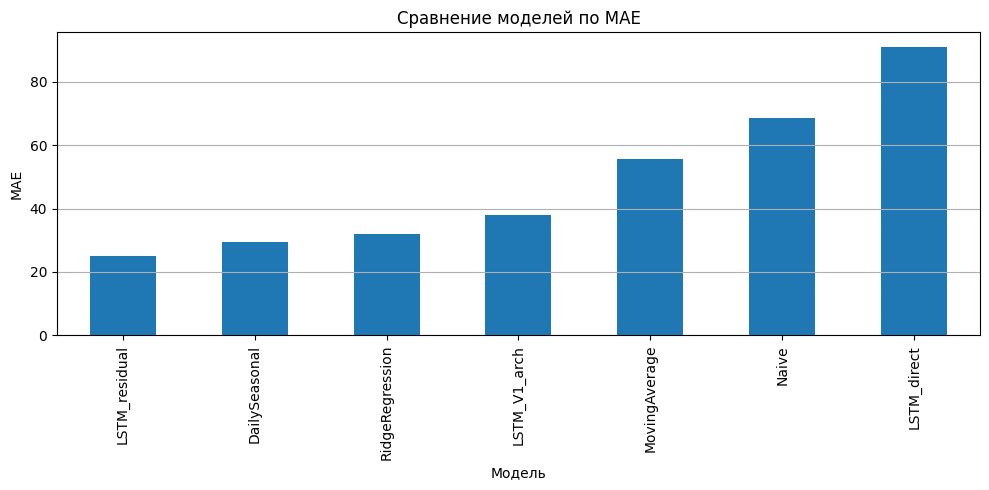

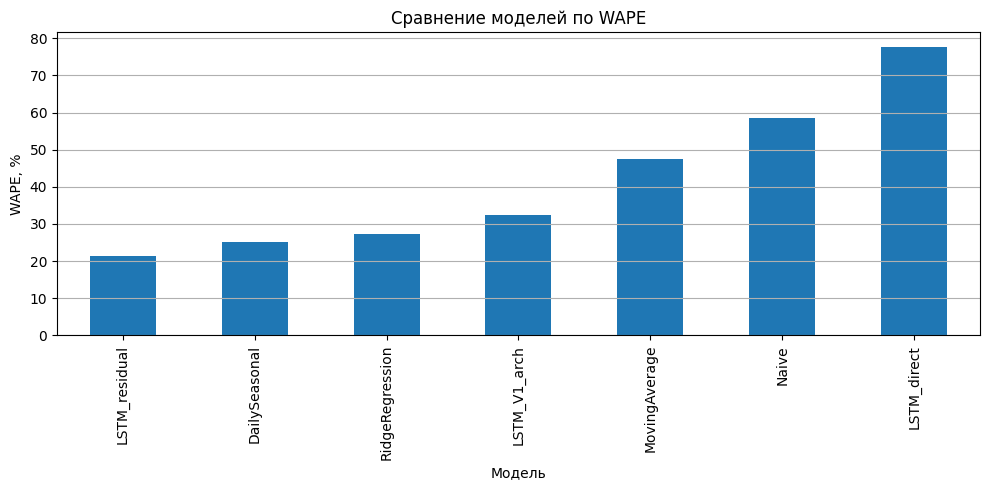

In [19]:
plt.figure(figsize=(10, 5))
results_df["MAE"].sort_values(ascending=True).plot(kind="bar")
plt.title("Сравнение моделей по MAE")
plt.xlabel("Модель")
plt.ylabel("MAE")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("models_comparison_mae.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
results_df["WAPE_%"].sort_values(ascending=True).plot(kind="bar")
plt.title("Сравнение моделей по WAPE")
plt.xlabel("Модель")
plt.ylabel("WAPE, %")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("models_comparison_wape.png", dpi=150)
plt.show()


## 19. Анализ процесса обучения

Графики функции потерь и MAE позволяют оценить, как проходило обучение нейросетевой модели.

Если train-loss и validation-loss снижаются синхронно, это говорит о стабильном обучении.

Если train-loss продолжает снижаться, а validation-loss растет, это может указывать на переобучение.

Для стабилизации обучения используются:

- Dropout;
- EarlyStopping;
- ReduceLROnPlateau;
- validation-выборка.

,loss,mae,val_loss,val_mae,learning_rate
10,0.187848,0.187848,0.223650,0.223650,0.0003
11,0.186920,0.186920,0.220951,0.220951,0.0003
12,0.186459,0.186459,0.220551,0.220551,0.0003
13,0.185567,0.185567,0.222663,0.222663,0.0003
14,0.184790,0.184790,0.221945,0.221945,0.0003


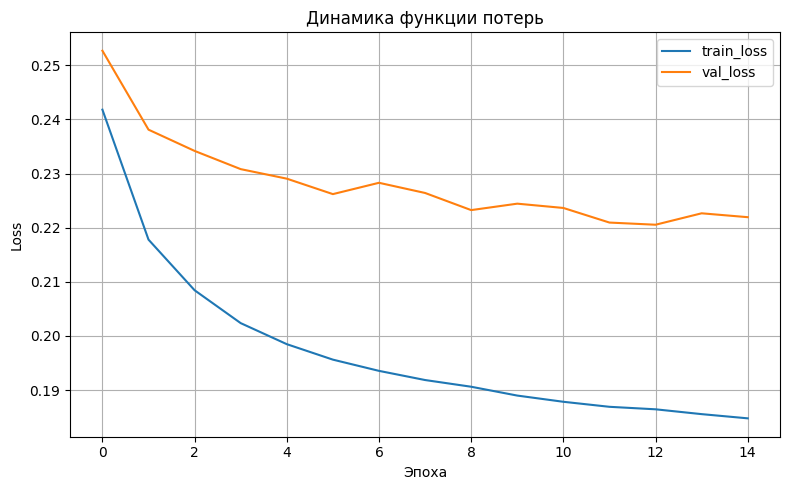

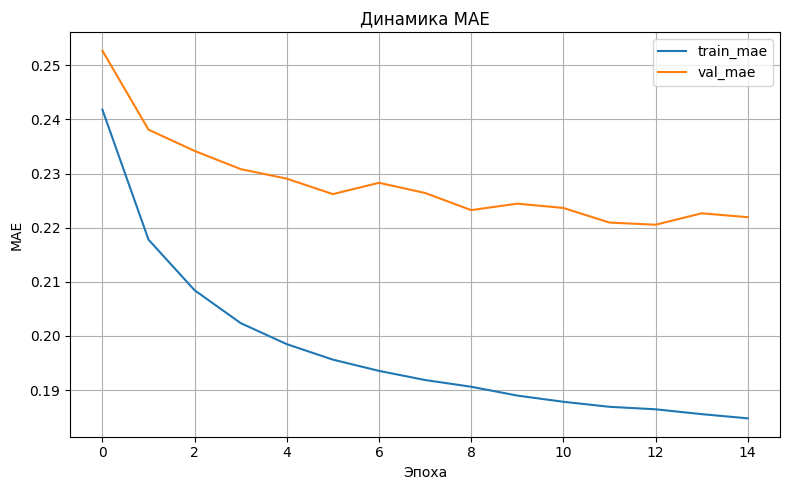

In [20]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Динамика функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["mae"], label="train_mae")
plt.plot(history_df["val_mae"], label="val_mae")
plt.title("Динамика MAE")
plt.xlabel("Эпоха")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_mae.png", dpi=150)
plt.show()


## 20. Проверка финальной модели относительно сильного baseline

Для временных рядов с выраженной сезонностью сильным baseline является `DailySeasonal`.

Поэтому важно проверить, улучшает ли финальная LSTM-модель сезонный прогноз. Если LSTM показывает меньшую MAE, значит она действительно добавляет полезную информацию поверх простой сезонной закономерности.

In [21]:
daily_mae = results_df.loc["DailySeasonal", "MAE"]
lstm_mae = results_df.loc["LSTM_residual", "MAE"]

print("DailySeasonal MAE:", daily_mae)
print("LSTM_residual MAE:", lstm_mae)

if lstm_mae <= daily_mae:
    print("OK: LSTM residual улучшила или повторила сезонный baseline")
else:
    print(
        "LSTM residual хуже сезонного baseline на test. Для отчёта честно указываем DailySeasonal как сильный baseline, а LSTM как экспериментальную модель"
    )


DailySeasonal MAE: 29.299118041992188
LSTM_residual MAE: 24.94801902770996
OK: LSTM residual улучшила или повторила сезонный baseline


## 21. Детальный анализ ошибок

Одной итоговой метрики недостаточно, чтобы понять поведение модели.

Поэтому дополнительно анализируются ошибки:

- по горизонту прогноза;
- по районам;
- по комбинации района и часа прогноза.

Такой анализ показывает, в каких ситуациях модель работает лучше или хуже.

Ошибки могут быть выше:

- в районах с высоким и нестабильным спросом;
- в часы пик;
- в районах с редкими поездками;
- в периоды резких изменений спроса.

### Ошибка по горизонту прогноза

,forecast_hour,MAE,RMSE,WAPE,R2
0,1,33.357712,94.605622,36.552612,0.633420
1,2,31.268002,96.827695,49.899784,0.466214
2,3,25.926390,86.641210,57.269947,0.339707
3,4,19.853552,68.670672,55.052364,0.229652
4,5,14.097315,43.588616,38.137287,0.309939
5,6,10.067193,24.893350,22.812159,0.672851
6,7,14.123871,25.848678,19.364363,0.857935
7,8,23.740969,41.991270,20.623417,0.857676
8,9,29.763189,51.618133,20.740967,0.861844
9,10,21.246910,37.856578,16.092371,0.912705


### Топ-10 активных районов с минимальной ошибкой

,location_id,samples,fact_sum,fact_mean,pred_sum,MAE,RMSE,WAPE,R2
261,264,64,16916.0,11.013021,16861.0,4.324870,5.859854,39.270515,0.384201
83,84,64,17931.0,11.673828,17570.0,4.474609,7.202385,38.330265,0.188783
43,44,64,17007.0,11.072266,16663.0,4.680990,7.758144,42.276711,0.006565
5,6,64,22973.0,14.956380,22524.0,4.797526,6.842109,32.076786,0.544800
63,64,64,25811.0,16.804037,25280.0,5.339193,7.842484,31.773275,0.518187
237,240,64,26084.0,16.981771,25527.0,5.530599,7.910099,32.567860,0.334603
169,172,64,25547.0,16.632162,25010.0,5.585287,7.837585,33.581242,0.496782
198,201,64,22246.0,14.483073,21793.0,5.645182,8.972215,38.977795,0.074564
184,187,64,29522.0,19.220053,28801.0,5.822266,8.259898,30.292664,0.567009
199,202,64,25616.0,16.677084,25037.0,5.935547,8.827226,35.591038,0.334025


### Топ-10 районов с максимальной ошибкой

,location_id,samples,fact_sum,fact_mean,pred_sum,MAE,RMSE,WAPE,R2
135,138,64,890535.0,579.775391,822684.0,180.184250,268.961879,31.078285,0.632848
78,79,64,691351.0,450.098297,684720.0,146.514969,299.869490,32.551773,0.463297
129,132,64,980502.0,638.347656,946283.0,140.796219,216.198621,22.056355,0.685879
227,230,64,729135.0,474.697266,701128.0,104.027992,157.890989,21.914597,0.770337
158,161,64,818347.0,532.778015,796448.0,102.270180,174.308393,19.195648,0.853012
246,249,64,535189.0,348.430328,517670.0,99.819664,177.731671,28.648386,0.634221
145,148,64,481458.0,313.449219,467723.0,98.828773,210.432293,31.529438,0.540499
243,246,64,555344.0,361.552094,518295.0,85.152992,131.529739,23.552069,0.770748
231,234,64,643002.0,418.621094,605055.0,80.777992,128.258673,19.296207,0.820581
252,255,64,398368.0,259.354156,364989.0,77.185547,142.002441,29.760674,0.575434


### Районы с минимальной MAE без фильтрации

,location_id,samples,fact_sum,fact_mean,pred_sum,MAE,RMSE,WAPE,R2
102,105,64,6.0,0.003906,7.0,0.008464,0.091998,216.666672,-1.175164
196,199,64,11.0,0.007161,10.0,0.013672,0.116927,190.909088,-0.922862
107,110,64,41.0,0.026693,42.0,0.052734,0.229640,197.560974,-1.029790
1,2,64,55.0,0.035807,55.0,0.067708,0.272431,189.090912,-0.931202
250,253,64,766.0,0.498698,752.0,0.592448,1.045202,118.798958,-0.393691
0,1,64,786.0,0.511719,787.0,0.632161,1.198686,123.536896,-0.425905
7,8,64,811.0,0.527995,796.0,0.654297,1.046136,123.921082,-0.745956
98,99,64,821.0,0.534505,809.0,0.671875,1.093899,125.700363,-0.756883
108,111,64,1151.0,0.749349,1120.0,0.860026,1.315225,114.769768,-0.681114
26,27,64,1200.0,0.781250,1171.0,0.902995,1.428185,115.583336,-0.722849


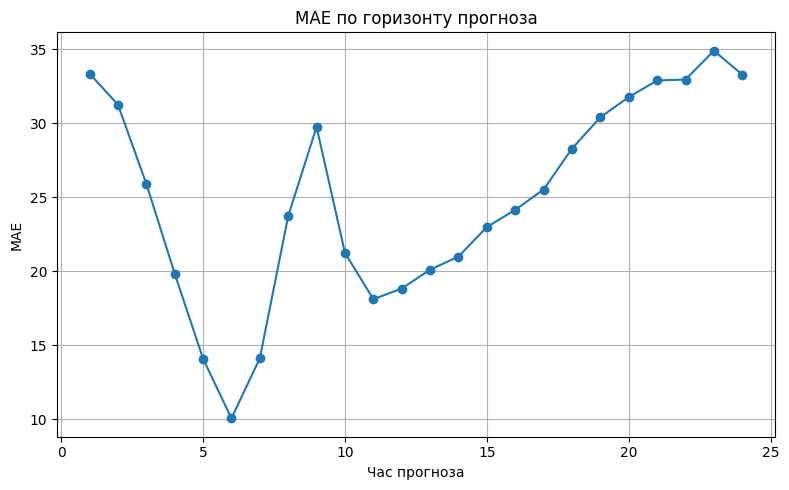

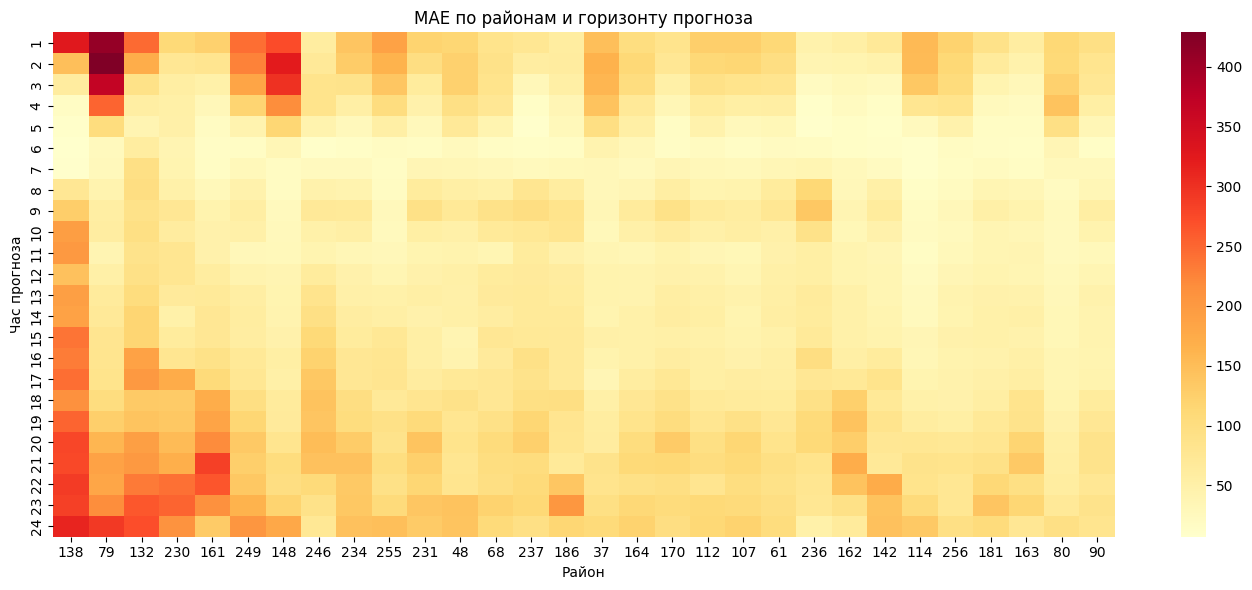

In [30]:
def detailed_analysis(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    regions_test: np.ndarray,
    loc2idx: dict[int, int],
    top_n: int = 10,
    max_regions_for_heatmap: int = 30,
    min_fact_sum_for_best: float = 1000,
    min_fact_mean_for_best: float = 10,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    idx2loc = {v: k for k, v in loc2idx.items()}

    horizon_rows = []

    for h in range(y_true.shape[1]):
        t = y_true[:, h]
        p = y_pred[:, h]

        horizon_rows.append(
            {
                "forecast_hour": h + 1,
                "MAE": mean_absolute_error(t, p),
                "RMSE": np.sqrt(mean_squared_error(t, p)),
                "WAPE": wape(t, p),
                "R2": r2_score(t, p),
            }
        )

    horizon_df = pd.DataFrame(horizon_rows)

    region_rows = []

    for region_idx in np.unique(regions_test):
        mask = regions_test == region_idx

        if mask.sum() == 0:
            continue

        t = y_true[mask].ravel()
        p = y_pred[mask].ravel()

        region_rows.append(
            {
                "location_id": idx2loc[int(region_idx)],
                "samples": int(mask.sum()),
                "fact_sum": float(t.sum()),
                "fact_mean": float(t.mean()),
                "pred_sum": float(p.sum()),
                "MAE": mean_absolute_error(t, p),
                "RMSE": np.sqrt(mean_squared_error(t, p)),
                "WAPE": wape(t, p),
                "R2": r2_score(t, p),
            }
        )

    region_df = pd.DataFrame(region_rows).sort_values("MAE")

    active_region_df = region_df[
        (region_df["fact_sum"] >= min_fact_sum_for_best)
        & (region_df["fact_mean"] >= min_fact_mean_for_best)
    ].copy()

    display(Markdown("### Ошибка по горизонту прогноза"))
    display(horizon_df)

    display(Markdown(f"### Топ-{top_n} активных районов с минимальной ошибкой"))
    display(active_region_df.sort_values("MAE").head(top_n))

    display(Markdown(f"### Топ-{top_n} районов с максимальной ошибкой"))
    display(region_df.sort_values("MAE", ascending=False).head(top_n))

    display(Markdown("### Районы с минимальной MAE без фильтрации"))
    display(region_df.sort_values("MAE").head(top_n))

    plt.figure(figsize=(8, 5))
    plt.plot(horizon_df["forecast_hour"], horizon_df["MAE"], marker="o")
    plt.title("MAE по горизонту прогноза")
    plt.xlabel("Час прогноза")
    plt.ylabel("MAE")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("mae_by_forecast_hour.png", dpi=150)
    plt.show()

    selected_regions = (
        region_df.sort_values("MAE", ascending=False)
        .head(max_regions_for_heatmap)["location_id"]
        .tolist()
    )

    selected_region_indices = [
        loc2idx[int(loc)] for loc in selected_regions if int(loc) in loc2idx
    ]

    err_matrix = np.zeros((y_true.shape[1], len(selected_region_indices)))

    for j, region_idx in enumerate(selected_region_indices):
        mask = regions_test == region_idx

        for h in range(y_true.shape[1]):
            err_matrix[h, j] = np.mean(np.abs(y_true[mask, h] - y_pred[mask, h]))

    plt.figure(figsize=(14, 6))
    sns.heatmap(
        err_matrix,
        xticklabels=[idx2loc[int(idx)] for idx in selected_region_indices],
        yticklabels=np.arange(1, y_true.shape[1] + 1),
        cmap="YlOrRd",
    )
    plt.title("MAE по районам и горизонту прогноза")
    plt.xlabel("Район")
    plt.ylabel("Час прогноза")
    plt.tight_layout()
    plt.savefig("mae_heatmap_regions_horizon.png", dpi=150)
    plt.show()

    horizon_df.to_csv("metrics_by_forecast_hour.csv", index=False)
    region_df.to_csv("metrics_by_region.csv", index=False)
    active_region_df.to_csv("metrics_by_active_region.csv", index=False)

    return horizon_df, region_df


horizon_df, region_df = detailed_analysis(
    y_true=data["y_test"],
    y_pred=y_lstm,
    regions_test=data["regions_test"],
    loc2idx=loc2idx,
    top_n=10,
    min_fact_sum_for_best=1000,
    min_fact_mean_for_best=10,
)


## 22. Пример прогноза на следующие 24 часа

Для наглядной проверки строится пример прогноза на одном объекте test-выборки.

На графике сравниваются:

- фактическое количество поездок;
- предсказание модели;
- ошибка по каждому часу прогноза.


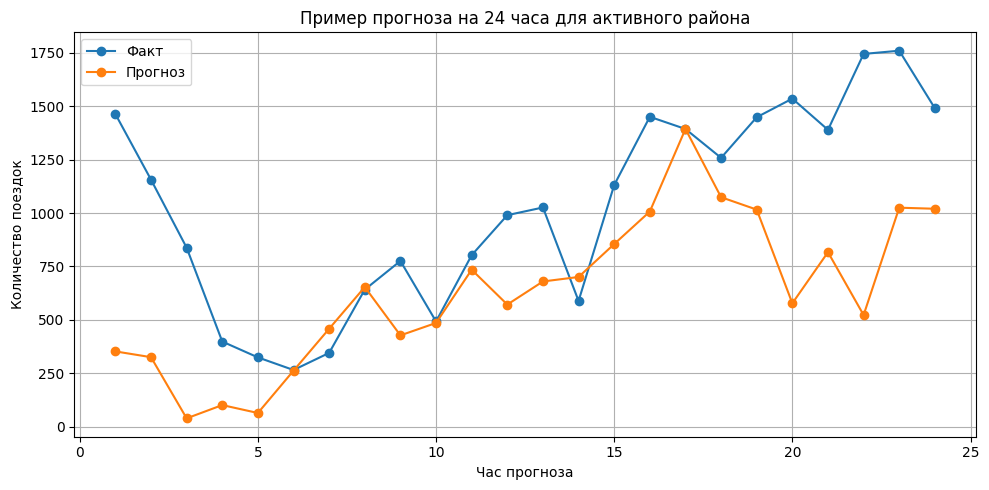

,forecast_hour,fact,prediction,abs_error
0,1,1463.0,353.0,1110.0
1,2,1156.0,326.0,830.0
2,3,838.0,40.0,798.0
3,4,399.0,102.0,297.0
4,5,325.0,65.0,260.0
5,6,266.0,263.0,3.0
6,7,346.0,459.0,113.0
7,8,642.0,654.0,12.0
8,9,776.0,428.0,348.0
9,10,493.0,486.0,7.0


In [29]:
sample_idx = int(np.argmax(data["y_test"].sum(axis=1)))

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, FUTURE_STEPS + 1),
    data["y_test"][sample_idx],
    marker="o",
    label="Факт",
)
plt.plot(
    np.arange(1, FUTURE_STEPS + 1),
    y_lstm[sample_idx],
    marker="o",
    label="Прогноз",
)
plt.title("Пример прогноза на 24 часа для активного района")
plt.xlabel("Час прогноза")
plt.ylabel("Количество поездок")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("example_forecast_24h_active_region.png", dpi=150)
plt.show()

comparison_df = pd.DataFrame(
    {
        "forecast_hour": np.arange(1, FUTURE_STEPS + 1),
        "fact": data["y_test"][sample_idx],
        "prediction": y_lstm[sample_idx],
        "abs_error": np.abs(data["y_test"][sample_idx] - y_lstm[sample_idx]),
    }
)

display(comparison_df)

## 23. Итоговая сводка результатов

В финальной таблице собраны основные значения, которые используются в отчете и презентации:

- лучшая модель;
- MAE итоговой LSTM-модели;
- WAPE итоговой LSTM-модели;
- качество прямой LSTM;
- улучшение относительно baseline-моделей;
- временные границы train/validation/test.

In [24]:
best_model = results_df.index[0]
best_mae = results_df.loc[best_model, "MAE"]

lstm_mae = results_df.loc["LSTM_residual", "MAE"]
seasonal_mae = results_df.loc["DailySeasonal", "MAE"]
ridge_mae = results_df.loc["RidgeRegression", "MAE"]
naive_mae = results_df.loc["Naive", "MAE"]

lstm_wape = results_df.loc["LSTM_residual", "WAPE_%"]
seasonal_wape = results_df.loc["DailySeasonal", "WAPE_%"]
ridge_wape = results_df.loc["RidgeRegression", "WAPE_%"]
naive_wape = results_df.loc["Naive", "WAPE_%"]

improvement_vs_naive = (naive_mae - lstm_mae) / naive_mae * 100
improvement_vs_seasonal = (seasonal_mae - lstm_mae) / seasonal_mae * 100
improvement_vs_ridge = (ridge_mae - lstm_mae) / ridge_mae * 100

train_start = pd.to_datetime(data["target_train"]).min()
train_end = pd.to_datetime(data["target_train"]).max()
val_start = pd.to_datetime(data["target_val"]).min()
val_end = pd.to_datetime(data["target_val"]).max()
test_start = pd.to_datetime(data["target_test"]).min()
test_end = pd.to_datetime(data["target_test"]).max()

summary_values = pd.DataFrame(
    {
        "Показатель": [
            "Лучшая модель",
            "MAE лучшей модели",
            "MAE LSTM_residual",
            "WAPE LSTM_residual",
            "Улучшение относительно Naive, %",
            "Улучшение относительно DailySeasonal, %",
            "Улучшение относительно RidgeRegression, %",
            "Train период",
            "Validation период",
            "Test период",
        ],
        "Значение": [
            best_model,
            round(best_mae, 3),
            round(lstm_mae, 3),
            round(lstm_wape, 2),
            round(improvement_vs_naive, 2),
            round(improvement_vs_seasonal, 2),
            round(improvement_vs_ridge, 2),
            f"{train_start.date()} - {train_end.date()}",
            f"{val_start.date()} - {val_end.date()}",
            f"{test_start.date()} - {test_end.date()}",
        ],
    }
)

display(summary_values)

,Показатель,Значение
0,Лучшая модель,LSTM_residual
1,MAE лучшей модели,24.948
2,MAE LSTM_residual,24.948
3,WAPE LSTM_residual,21.3
4,"Улучшение относительно Naive, %",63.65
5,"Улучшение относительно DailySeasonal, %",14.85
6,"Улучшение относительно RidgeRegression, %",21.89
7,Train период,2024-01-04 - 2024-10-24
8,Validation период,2024-10-25 - 2024-12-26
9,Test период,2024-12-27 - 2025-02-28


## 24. Выводы

В рамках работы был построен полный пайплайн прогнозирования почасового спроса на такси по районам.

Были выполнены следующие этапы:

- загружены и объединены данные о поездках;
- данные агрегированы до уровня `район + час`;
- сформирована полная почасовая сетка районов;
- добавлены календарные, погодные, лаговые и rolling-признаки;
- сформированы обучающие последовательности;
- выполнено корректное временное разделение на train, validation и test;
- обучены baseline-модели, RidgeRegression, LSTM_direct, LSTM_V1_arch и LSTM_residual;
- проведено сравнение моделей по MAE, RMSE, WAPE, sMAPE и R²;
- выполнен анализ ошибок по районам и горизонту прогноза.

Финальная модель `LSTM_residual` использует сезонный baseline `DailySeasonal` и обучается корректировать его ошибки. Такой подход оказался полезным, потому что спрос на такси имеет выраженную суточную сезонность.

Сравнение моделей показывает, что итоговая LSTM-модель превосходит простые baseline-подходы и может использоваться для прогноза почасового спроса на такси по районам.

Практическое применение модели:

- предварительное распределение автомобилей по районам;
- снижение времени ожидания пассажирами;
- уменьшение простоя водителей;
- планирование нагрузки в часы пик;
- поддержка аналитики городской мобильности.

Основные направления дальнейшего развития:

- подобрать оптимальный `SEQUENCE_STRIDE`;
- добавить данные о городских событиях;
- расширить погодные признаки;
- протестировать CatBoost/XGBoost на табличной постановке;
- реализовать регулярное переобучение модели;
- добавить мониторинг качества прогноза по районам.